# Model Metrics Comparison
## Precision, Recall, and F1 Score Analysis

This notebook loads and compares precision, recall, and F1 scores from all models in the outputs/ directory.

In [123]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re


plt.style.use("seaborn-v0_8-paper")
sns.set_palette("pastel")
plt.rcParams["figure.figsize"] = (10, 10)
plt.rcParams["font.family"] = "Courier New"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 20
plt.rcParams["figure.dpi"] = 300

## 1. Load Metrics from All Models

In [124]:
def parse_eval_report(filepath):
    """Parse eval_report.txt and extract precision, recall, F1 score, and support from weighted avg."""
    try:
        with open(filepath, 'r') as f:
            content = f.read()
        
        # Extract weighted avg metrics from classification report table
        # Format: "   weighted avg       0.50      0.50      0.50       447"
        weighted_avg_match = re.search(r'weighted avg\s+([0-9.]+)\s+([0-9.]+)\s+([0-9.]+)\s+([0-9]+)', content)
        
        if weighted_avg_match:
            return {
                'precision': float(weighted_avg_match.group(1)),
                'recall': float(weighted_avg_match.group(2)),
                'f1': float(weighted_avg_match.group(3)),
                'support': int(weighted_avg_match.group(4))
            }
    except Exception as e:
        print(f"Error parsing {filepath}: {e}")
    
    return None

def load_all_metrics(base_dir='../outputs/final'):
    """Load metrics from all model directories."""
    base_path = Path(base_dir)
    metrics_data = []
    
    for model_dir in base_path.iterdir():
        if not model_dir.is_dir():
            continue
        
        eval_report = model_dir / 'eval_report.txt'
        if eval_report.exists():
            metrics = parse_eval_report(eval_report)
            if metrics:
                metrics['model'] = model_dir.name
                metrics_data.append(metrics)
                print(f"Loaded metrics from {model_dir.name}")
    
    return pd.DataFrame(metrics_data)

# Load all metrics
df = load_all_metrics()
print(f"\nLoaded metrics from {len(df)} models")
df

Loaded metrics from createdelete-swing
Loaded metrics from removedirs
Loaded metrics from varmail
Loaded metrics from webproxy
Loaded metrics from openfiles
Loaded metrics from copyfiles
Loaded metrics from oltp
Loaded metrics from webserver
Loaded metrics from fileserver
Loaded metrics from randomread
Loaded metrics from mongo
Loaded metrics from fivestreamread
Loaded metrics from createfiles

Loaded metrics from 13 models


,precision,recall,f1,support,model
0,0.98,0.98,0.98,1793,createdelete-swing
1,0.98,0.98,0.98,1636,removedirs
2,0.77,0.77,0.77,651385,varmail
3,0.61,0.61,0.61,8358180,webproxy
4,0.95,0.95,0.95,4627,openfiles
5,0.98,0.98,0.98,905,copyfiles
6,0.67,0.67,0.67,221598,oltp
7,0.57,0.57,0.57,3712552,webserver
8,0.55,0.55,0.55,11555168,fileserver
9,0.70,0.70,0.70,2625545,randomread


## 2. Display Summary Statistics

In [125]:
if len(df) == 0:
    print("No models found! Check that eval_report.txt files exist in the outputs directory.")
else:
    print("Summary Statistics:")
    print("=" * 60)
    print(df[['precision', 'recall', 'f1']].describe())
    print("\nModels sorted by F1 Score:")
    print("=" * 60)
    display(df.sort_values('f1', ascending=False))

Summary Statistics:
       precision     recall         f1
count  13.000000  13.000000  13.000000
mean    0.796923   0.796923   0.796923
std     0.177077   0.177077   0.177077
min     0.550000   0.550000   0.550000
25%     0.660000   0.660000   0.660000
50%     0.770000   0.770000   0.770000
75%     0.970000   0.970000   0.970000
max     0.980000   0.980000   0.980000

Models sorted by F1 Score:


,precision,recall,f1,support,model
0,0.98,0.98,0.98,1793,createdelete-swing
1,0.98,0.98,0.98,1636,removedirs
5,0.98,0.98,0.98,905,copyfiles
10,0.97,0.97,0.97,8203,mongo
12,0.97,0.97,0.97,5579,createfiles
4,0.95,0.95,0.95,4627,openfiles
2,0.77,0.77,0.77,651385,varmail
9,0.70,0.70,0.70,2625545,randomread
6,0.67,0.67,0.67,221598,oltp
11,0.66,0.66,0.66,25320904,fivestreamread


## 3. Create Grouped Bar Chart

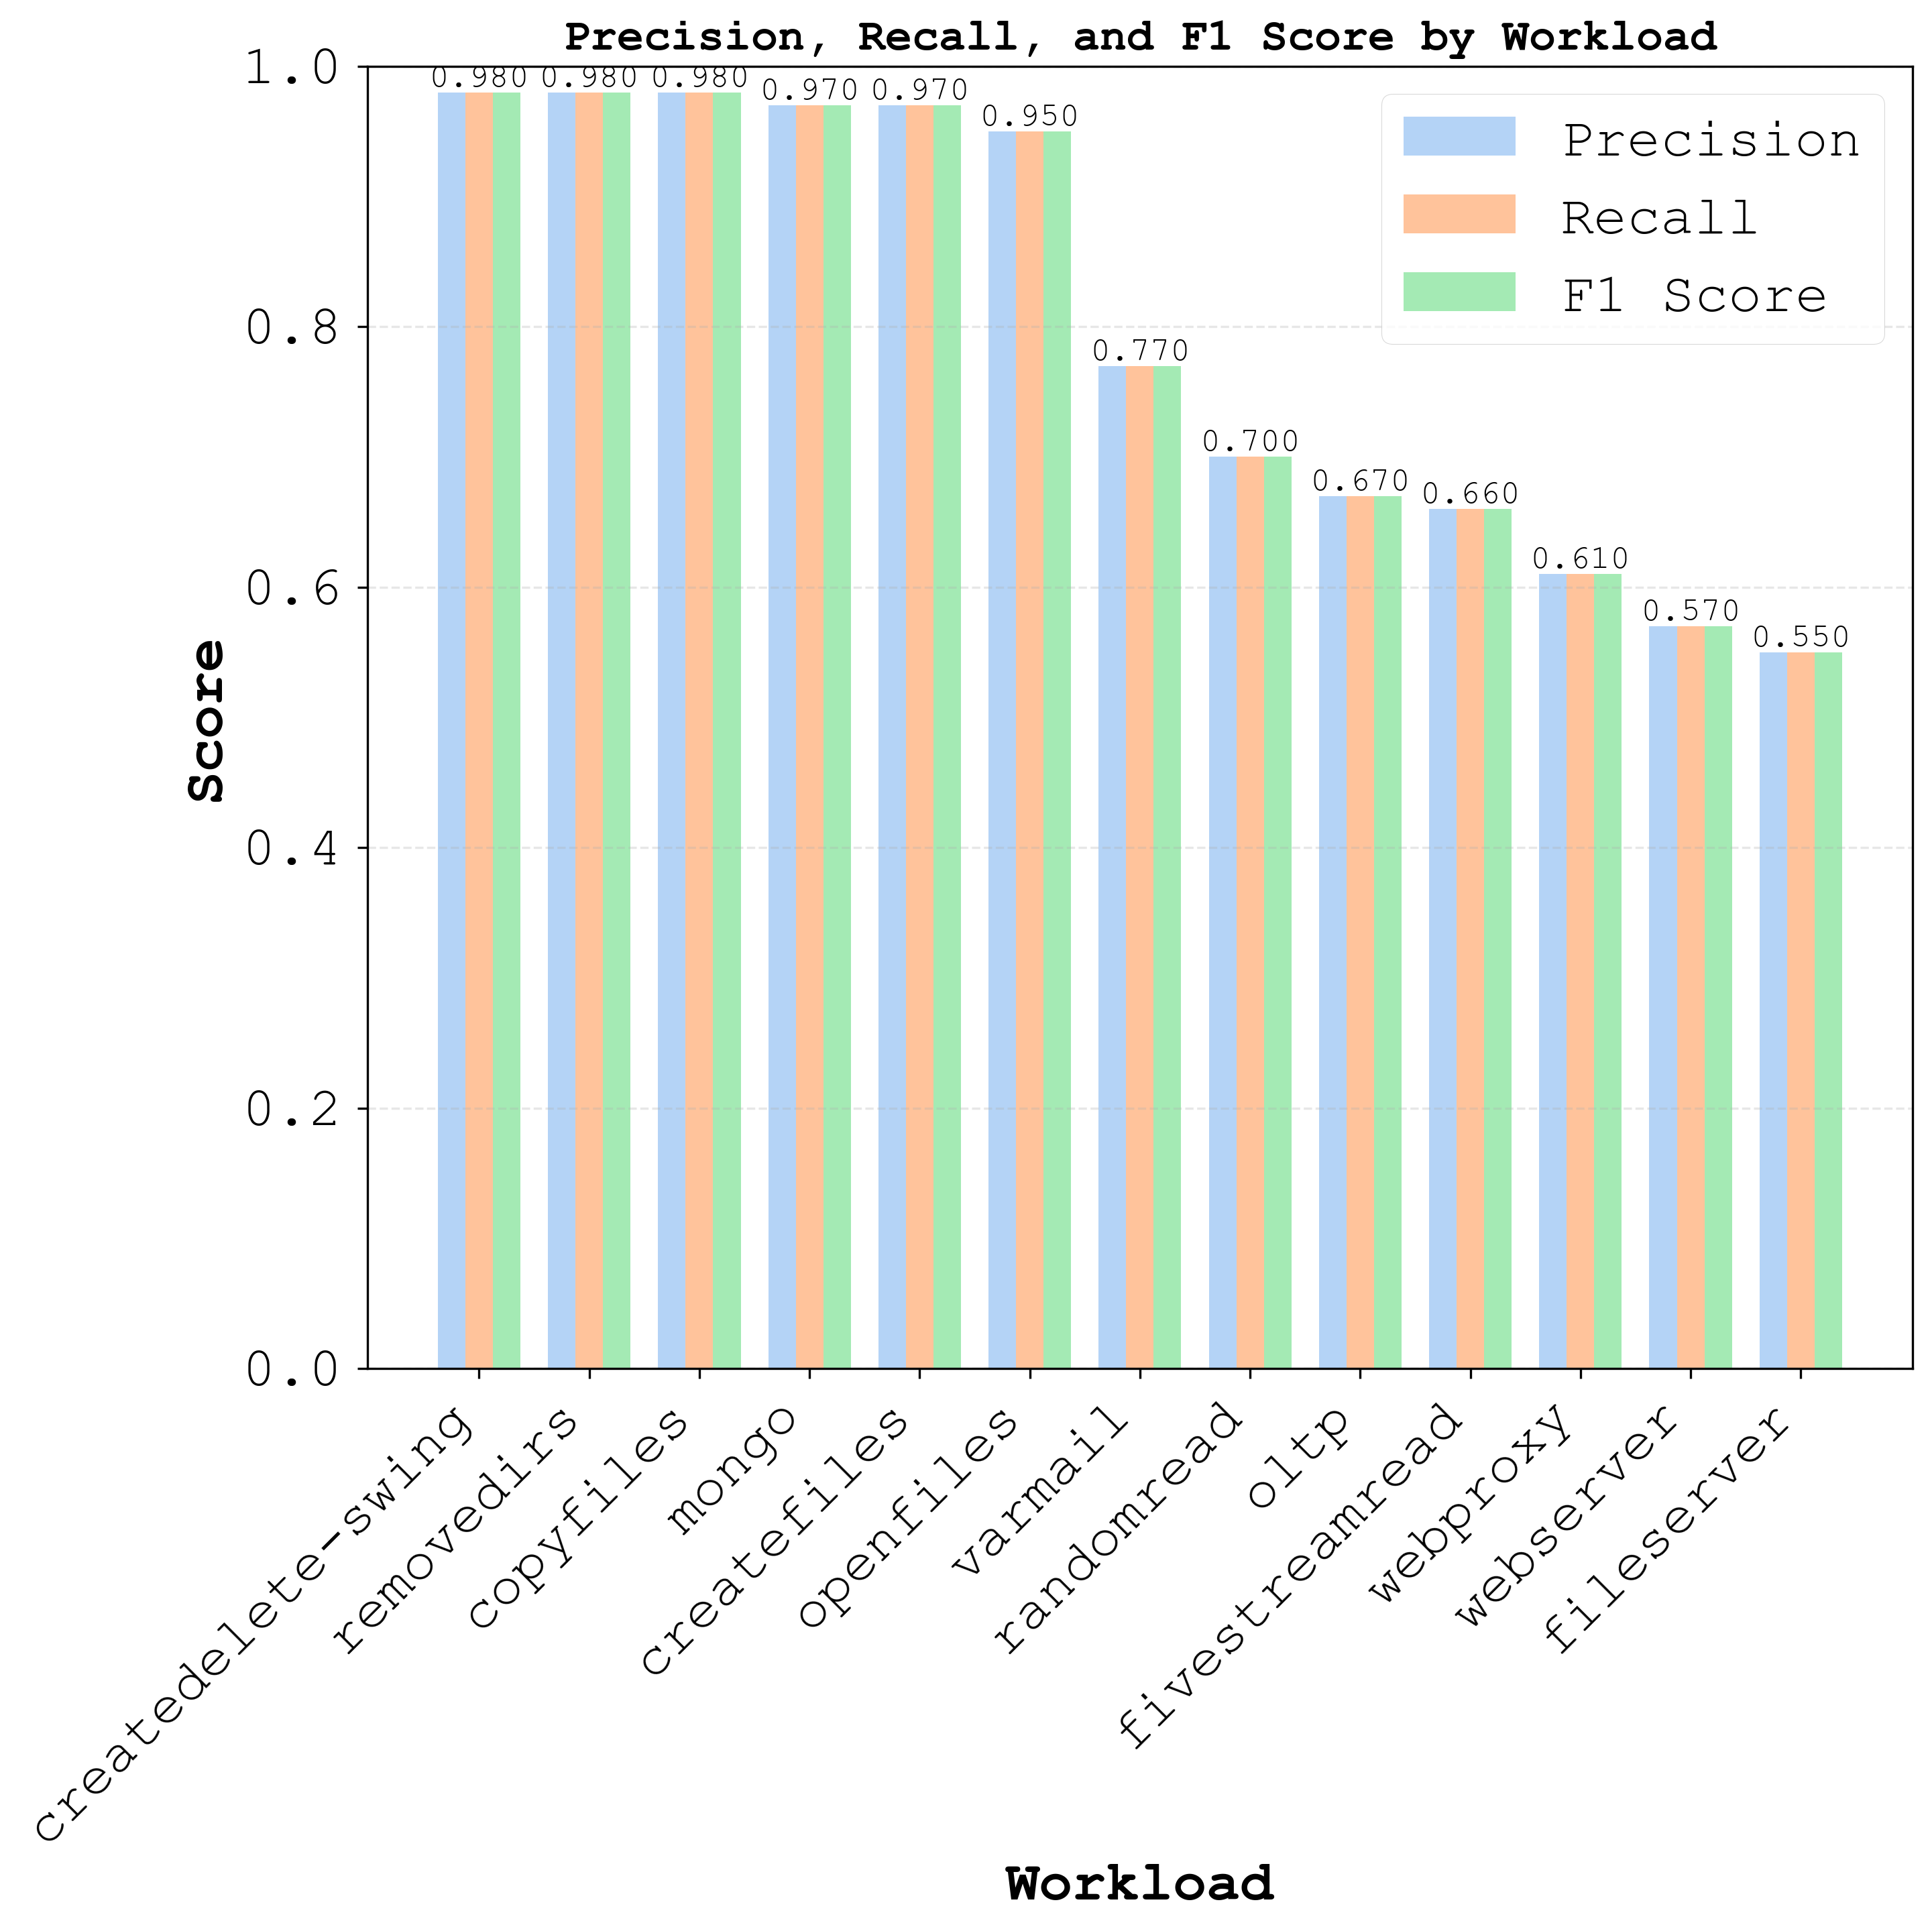

In [126]:
if len(df) == 0:
    print("No data to plot!")
else:
    df_sorted = df.sort_values('f1', ascending=False)
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    x = np.arange(len(df_sorted))
    width = 0.25
    
    bars1 = ax.bar(x - width, df_sorted['precision'], width, label='Precision', alpha=0.8)
    bars2 = ax.bar(x, df_sorted['recall'], width, label='Recall', alpha=0.8)
    bars3 = ax.bar(x + width, df_sorted['f1'], width, label='F1 Score', alpha=0.8)
    
    ax.set_xlabel('Workload', fontweight='bold')
    ax.set_ylabel('Score', fontweight='bold')
    ax.set_title('Precision, Recall, and F1 Score by Workload', fontweight='bold', fontsize=16)
    ax.set_xticks(x)
    ax.set_xticklabels(df_sorted['model'], rotation=45, ha='right')
    ax.legend(loc='upper right')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_ylim(0, 1.0)
    
    def add_value_labels(bars):
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                    f'{height:.3f}',
                    ha='center', va='bottom', fontsize=12)
    
    add_value_labels(bars2)
    
    plt.tight_layout()
    plt.show()

## 4. Support vs F1 Score Trend

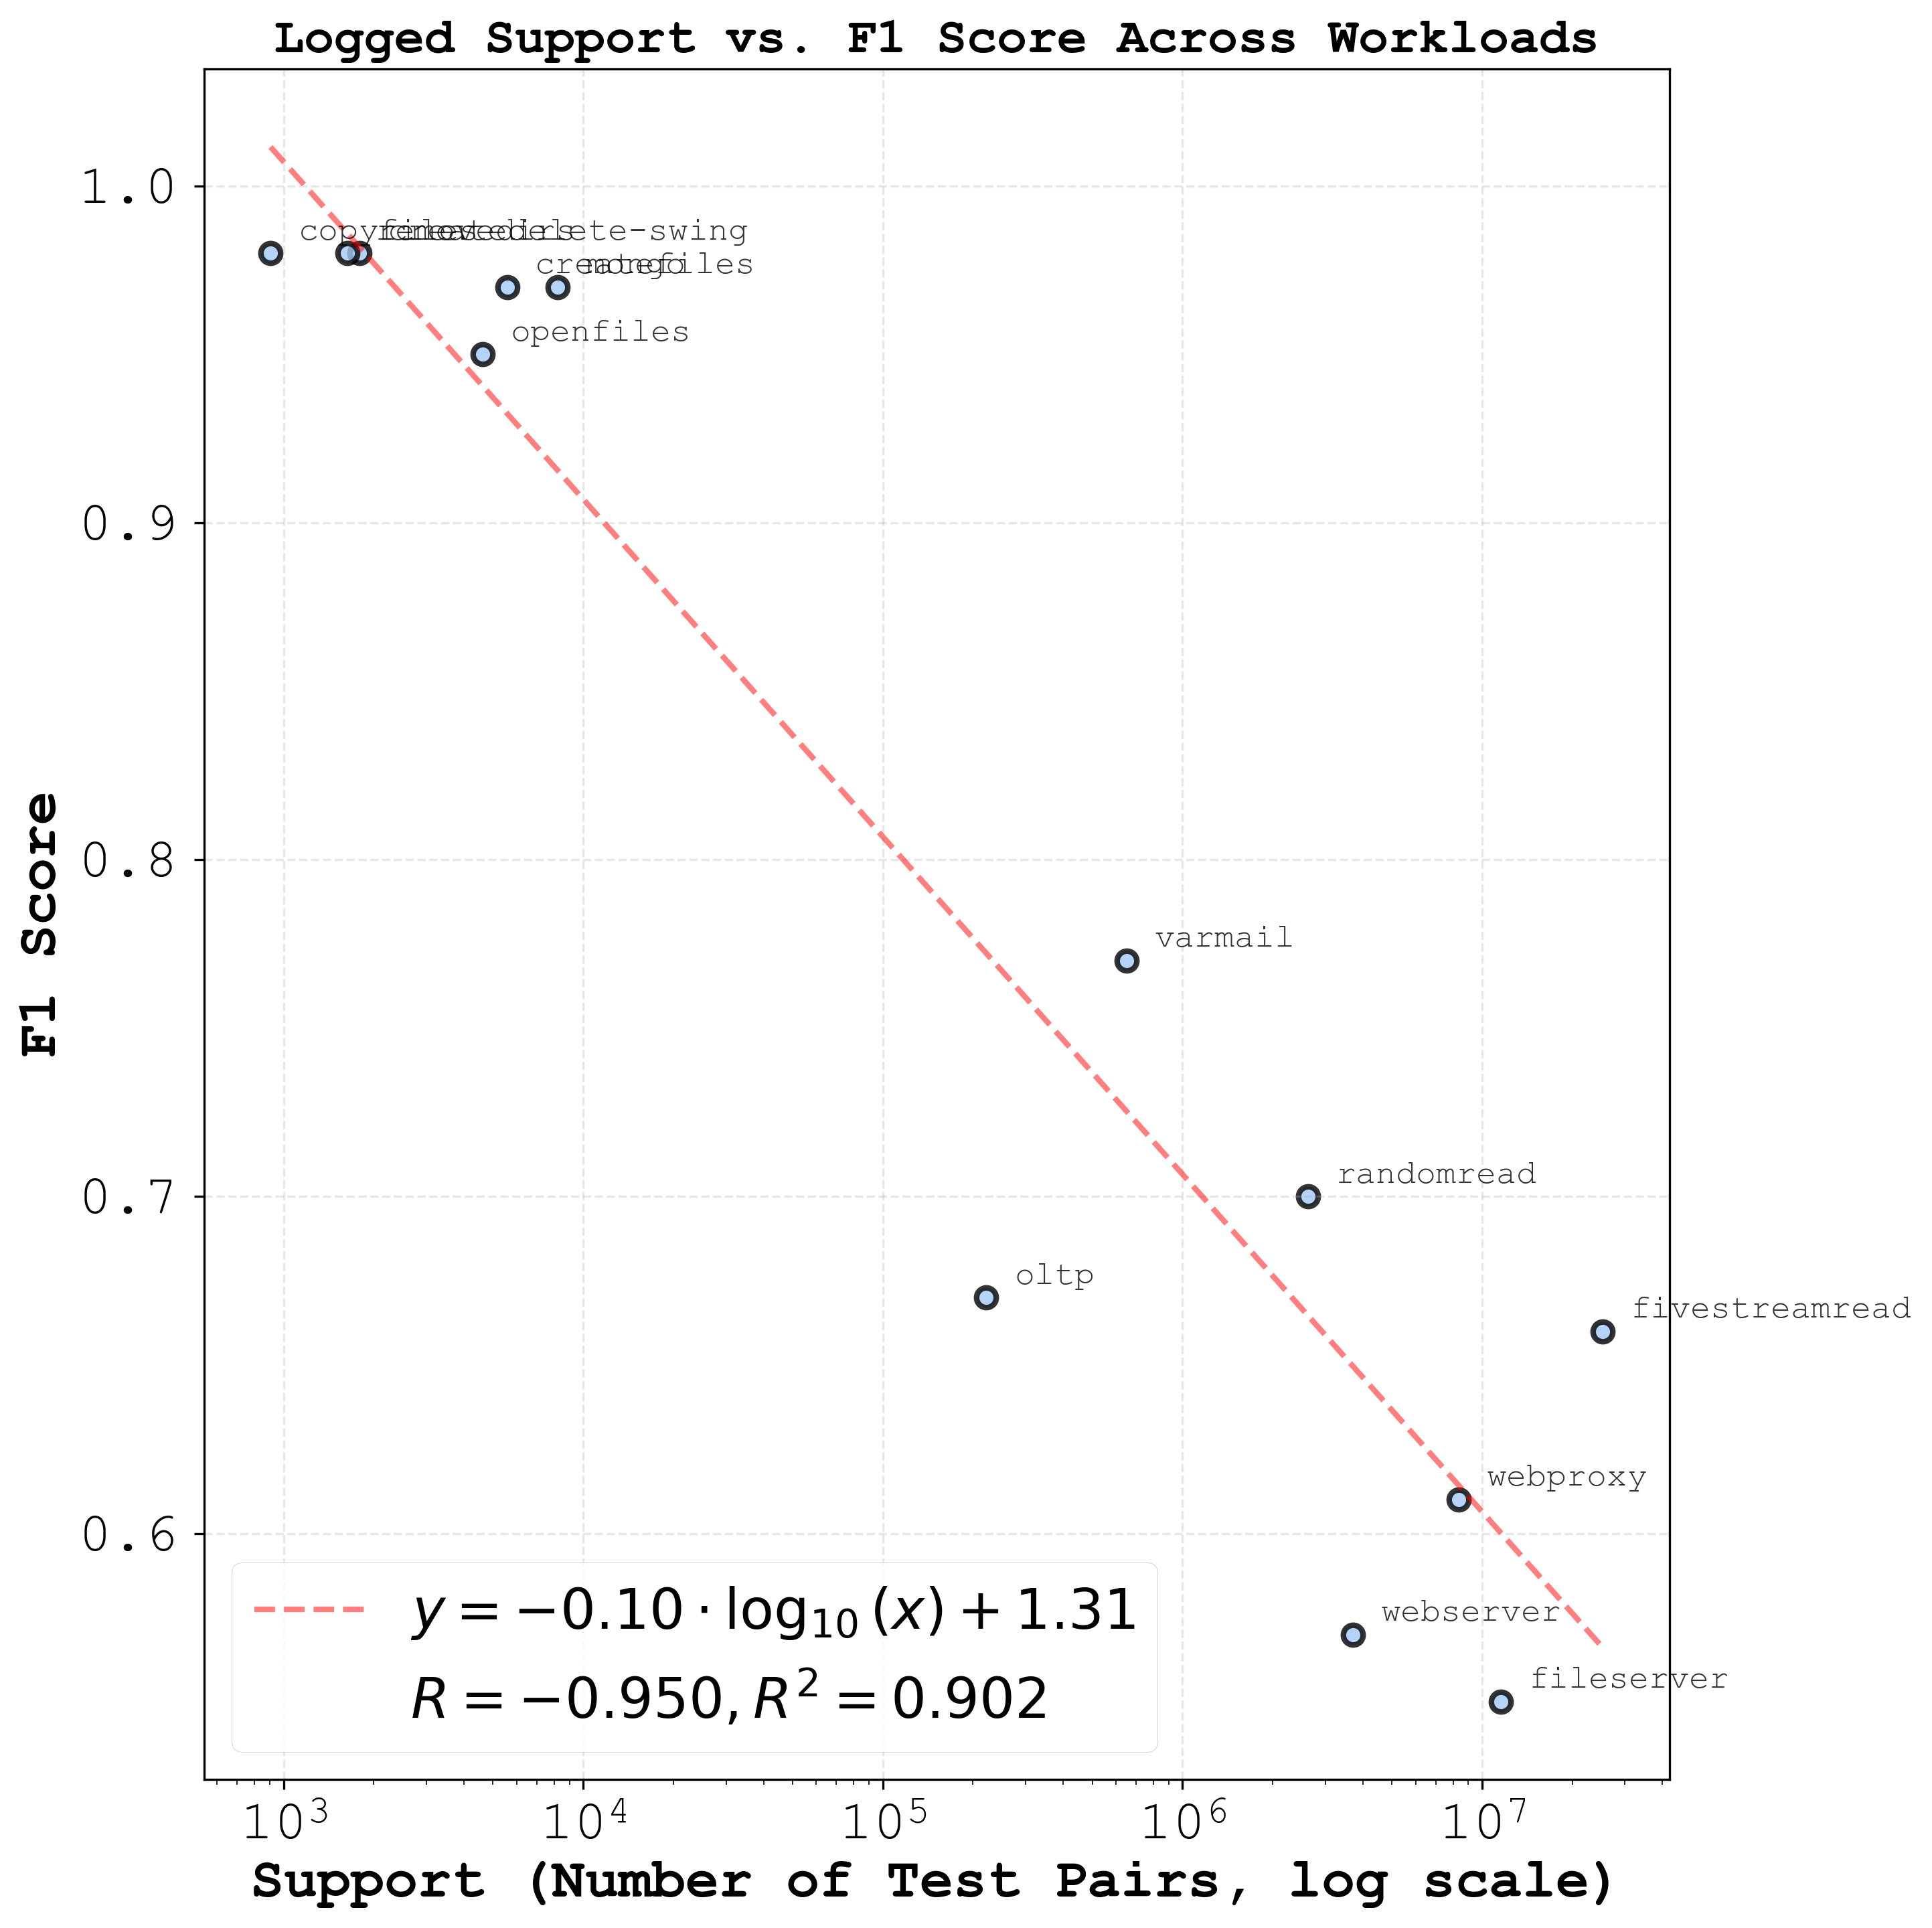

In [127]:
fig, ax = plt.subplots(figsize=(10, 10))

scatter = ax.scatter(df['support'], df['f1'], s=50, alpha=0.8, edgecolors='black', linewidth=2)

for idx, row in df.iterrows():
    ax.annotate(row['model'], 
                (row['support'], row['f1']),
                xytext=(10, 5), 
                textcoords='offset points',
                fontsize=12,
                alpha=0.8)

log_support = np.log10(df['support'])
z = np.polyfit(log_support, df['f1'], 1)
p = np.poly1d(z)
support_sorted = np.sort(df['support'])
log_support_sorted = np.log10(support_sorted)

predicted = p(log_support)
r = np.corrcoef(log_support, df['f1'])[0, 1]
r_squared = r**2

ax.plot(support_sorted, p(log_support_sorted), "r--", alpha=0.5, linewidth=2, 
        label=rf'$y = {z[0]:.2f} \cdot \log_{{10}}(x) + {z[1]:.2f}$')

ax.plot([], [], ' ', label=rf'$R = {r:.3f}, R^2 = {r_squared:.3f}$')

ax.set_xlabel('Support (Number of Test Pairs, log scale)', fontweight='bold')
ax.set_ylabel('F1 Score', fontweight='bold')
ax.set_title('Logged Support vs. F1 Score Across Workloads', fontweight='bold', fontsize=18)
ax.grid(True, alpha=0.3, linestyle='--')
ax.legend(loc='best')

ax.set_xscale('log')

plt.tight_layout()
plt.show()


## 5. Residual Plot

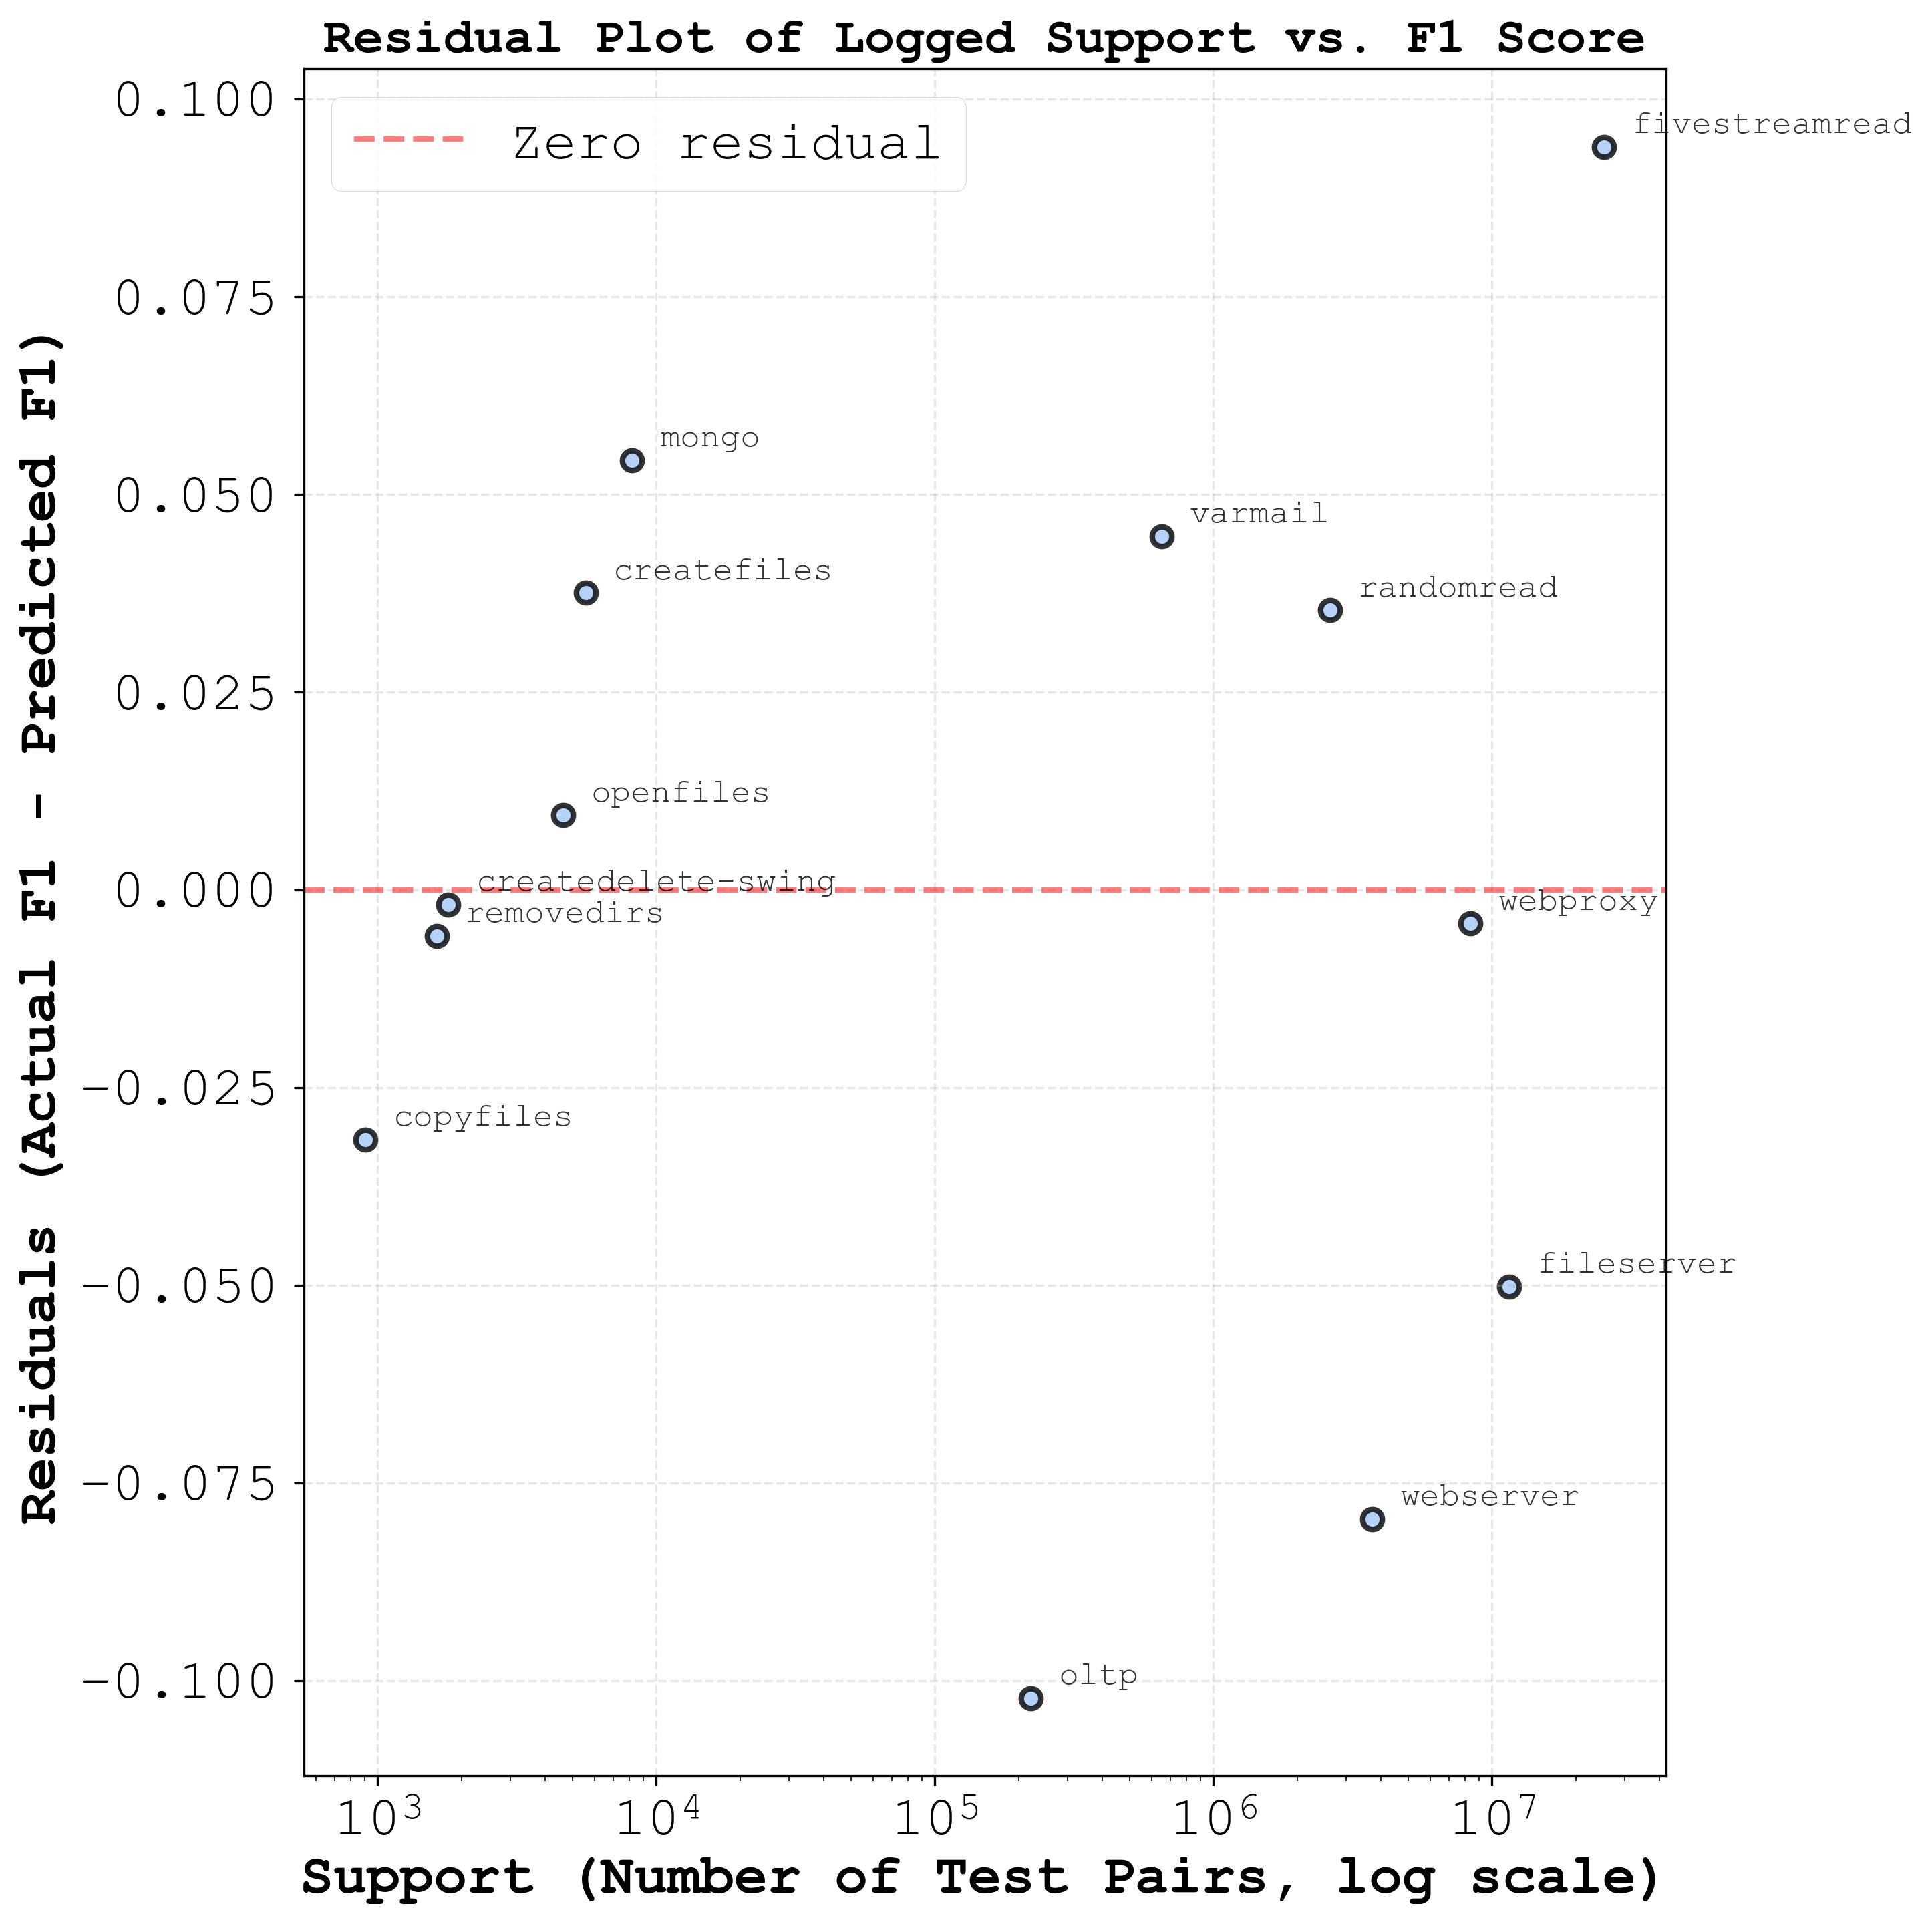

\nResidual Statistics:
Mean residual: 0.000000
Std deviation: 0.055439
Max positive residual: 0.093981 (fivestreamread)
Max negative residual: -0.102214 (oltp)


In [128]:
if len(df) == 0:
    print("No data to plot!")
else:
    log_support = np.log10(df['support'])
    z = np.polyfit(log_support, df['f1'], 1)
    p = np.poly1d(z)
    predicted = p(log_support)
    residuals = df['f1'] - predicted
    
    fig, ax = plt.subplots(figsize=(10, 10))
    
    ax.scatter(df['support'], residuals, s=50, alpha=0.8, edgecolors='black', linewidth=2)
    
    ax.axhline(y=0, color='r', linestyle='--', linewidth=2, alpha=0.5, label='Zero residual')
    
    for idx, row in df.iterrows():
        ax.annotate(row['model'], 
                   (row['support'], residuals[idx]),
                   xytext=(10, 5), 
                   textcoords='offset points',
                   fontsize=12,
                   alpha=0.8)
    
    ax.set_xlabel('Support (Number of Test Pairs, log scale)', fontweight='bold')
    ax.set_ylabel('Residuals (Actual F1 - Predicted F1)', fontweight='bold')
    ax.set_title('Residual Plot of Logged Support vs. F1 Score', fontweight='bold', fontsize=18)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.legend(loc='best')
    
    ax.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\\nResidual Statistics:")
    print(f"Mean residual: {residuals.mean():.6f}")
    print(f"Std deviation: {residuals.std():.6f}")
    print(f"Max positive residual: {residuals.max():.6f} ({df.loc[residuals.idxmax(), 'model']})")
    print(f"Max negative residual: {residuals.min():.6f} ({df.loc[residuals.idxmin(), 'model']})")